# ngp-precision: medicion de precision del Polo Norte Galactico
### Extension de `ngp-improvement` con z_sun, trazadores jovenes, presupuesto de error honesto y polo cinematico

**Cambio SDD**: `ngp-precision` (siete capacidades F1-F7 sobre el pipeline `ngp-improvement`).
**Autor de la propuesta original**: L. Cano (2022), *Approximation.ipynb*, `automatedAR.py`, `automatedDEC.py`, `DEC2.py` (no modificados).
**Este notebook**: se ejecuta ENTERAMENTE fuera de linea a partir de caches locales (`data/*.csv`,
`results/*.csv`/`.json`) generados por el batch B7 del ciclo `ngp-precision` -- no realiza
ninguna llamada de red.


## 1. Introduccion

El ciclo `ngp-improvement` (cerrado) establecio un pipeline reproducible con Gaia DR3 y un
estimador de circulo maximo (`great_circle_pole`) sin parametros libres como su resultado
insignia: alpha=12.9463h, delta=26.49 deg, con un error angular total de **1.44 deg** frente al
polo IAU y un CI95 bootstrap que **excluye** el valor IAU (27.13 deg) de forma estadisticamente
robusta.

`ngp-precision` toma ese residuo documentado como pregunta cientifica y lo convierte en ciencia:

1. **z_sun (altura del Sol sobre el plano)** -- el ajuste de circulo maximo de `ngp-improvement`
   pasa por el origen (el Sol), lo que ignora que el Sol puede estar desplazado del plano medio
   del disco. Un ajuste de plano con **offset libre** (`ngp_offset_plane.py`) recupera ese offset.
2. **Trazadores jovenes** -- Cefeidas, estrellas OB y cumulos abiertos jovenes trazan mejor el
   plano de rotacion actual que la muestra de disco de todas las edades usada en `ngp-improvement`.
3. **Error sistematico honesto** -- en vez de reportar solo el CI95 del bootstrap (que solo captura
   ruido de remuestreo), se construye una matriz de sistematicos (`systematics.py`) variando cada
   eleccion de analisis (corte en |b|, magnitud, S/N, distancia, hemisferio) para medir cuanto se
   mueve el polo -- la definicion operacional de un error *sistematico*.
4. **Polo cinematico** -- el eje de rotacion del disco, derivado de movimientos propios
   (`ngp_kinematic.py`), es un observable fisicamente independiente de la posicion estelar; su
   acuerdo (o desacuerdo) con el polo geometrico es una validacion cruzada fuerte.
5. **Forense de la convencion IAU** -- se descompone la divergencia entre nuestra medicion y el
   polo IAU publicado en un presupuesto de tres terminos (error de medicion de 1958, artefacto
   FK4->FK5, y gas-vs-estrellas) usando `iau_forensics.py`.

Este notebook presenta los resultados **reales** (no sinteticos) de las 7 capacidades sobre datos
de Gaia DR3 descargados en este mismo batch (Cefeidas: 15,021 filas crudas -> 394 tras corte
R<9kpc; estrellas OB: 11,196 -> 9,917; cumulos abiertos jovenes de Cantat-Gaudin: 2,017 -> 455
jovenes con R<9kpc), ademas de la muestra de disco de `ngp-improvement` (53,082 estrellas) como
referencia de comparacion.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from ngp_3d import great_circle_pole
from ngp_offset_plane import offset_plane_pole, delta_vs_distance_shells
from ngp_weighted_3d import weighted_tls_plane
from ngp_kinematic import kinematic_pole
from systematics import combine_error_budget, _angular_separation_deg as sys_angsep
from bootstrap import bootstrap_great_circle_pole
from iau_forensics import (
    IAU_B1950_POLE, IAU_J2000_POLE, KM2017_POLE,
    b1950_to_j2000_pole, decompose_divergence,
)
from report import build_master_table, save_report

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

IAU_ALPHA_H, IAU_DELTA_DEG = 12.85, 27.13
print("Notebook NGP_Precision -- 100% offline, lee caches locales de data/ y results/")


Notebook NGP_Precision -- 100% offline, lee caches locales de data/ y results/


## 2. z_sun: el offset del plano y la altura del Sol

`ngp_offset_plane.offset_plane_pole` extiende `great_circle_pole` con un offset libre (PCA
ponderada con centrado en la media, en vez de forzar el ajuste por el origen). Esto recupera
simultaneamente el polo Y la altura del Sol sobre el plano ajustado (z_sun, en parsecs).


In [2]:
disk = pd.read_csv("data/gaia_disk_stars.csv")
print(f"Estrellas de disco cacheadas (ngp-improvement): {len(disk)}")

op_disk = offset_plane_pole(disk)
print(f"offset_plane_pole (disco completo, N={op_disk['n_stars']}):")
print(f"  alpha_NGP = {op_disk['alpha_NGP']:.4f} h,  delta_NGP = {op_disk['delta_NGP']:.4f} deg")
print(f"  z_sun_pc  = {op_disk['z_sun_pc']:.2f} +- {op_disk['z_sun_err_pc']:.2f} pc")
print(f"  zero_point_corrected = {op_disk['zero_point_corrected']}")


Estrellas de disco cacheadas (ngp-improvement): 53082
offset_plane_pole (disco completo, N=53082):
  alpha_NGP = 12.9666 h,  delta_NGP = 25.6742 deg
  z_sun_pc  = -16.57 +- 1.62 pc
  zero_point_corrected = False


In [3]:
display(Markdown(
    f"**Comparacion con la literatura**: Karim & Mamajek (2017) reportan z_sun=17+-5 pc; la "
    f"propuesta de este ciclo cita una mediana historica de ~17+-2 pc. Nuestra medicion sobre la "
    f"muestra completa de disco da **z_sun = {op_disk['z_sun_pc']:.1f} +- {op_disk['z_sun_err_pc']:.1f} pc** "
    f"-- de magnitud comparable pero de **signo opuesto** al esperado (el Sol aparece por debajo "
    f"del plano ajustado, no por encima). Esta es una discrepancia real y honesta que reportamos "
    f"sin suavizar: es consistente con la conclusion central de este ciclo (ver Sec. 6) de que la "
    f"muestra de disco de *todas las edades*, limitada en magnitud/latitud galactica (|b|<15deg, "
    f"G<15), sufre sesgos sistematicos de seleccion (incompletitud diferencial por extincion, no "
    f"necesariamente simetrica en longitud galactica) del orden de ~1deg en el polo -- un "
    f"desplazamiento de decenas de pc en z_sun es plausible bajo el mismo mecanismo. Ver Sec. 4 "
    f"para el contraste con el metodo 3D ponderado (`weighted_tls_plane`), que da z_sun consistente "
    f"con cero pero con un error tan grande que resulta no informativo."
))


**Comparacion con la literatura**: Karim & Mamajek (2017) reportan z_sun=17+-5 pc; la propuesta de este ciclo cita una mediana historica de ~17+-2 pc. Nuestra medicion sobre la muestra completa de disco da **z_sun = -16.6 +- 1.6 pc** -- de magnitud comparable pero de **signo opuesto** al esperado (el Sol aparece por debajo del plano ajustado, no por encima). Esta es una discrepancia real y honesta que reportamos sin suavizar: es consistente con la conclusion central de este ciclo (ver Sec. 6) de que la muestra de disco de *todas las edades*, limitada en magnitud/latitud galactica (|b|<15deg, G<15), sufre sesgos sistematicos de seleccion (incompletitud diferencial por extincion, no necesariamente simetrica en longitud galactica) del orden de ~1deg en el polo -- un desplazamiento de decenas de pc en z_sun es plausible bajo el mismo mecanismo. Ver Sec. 4 para el contraste con el metodo 3D ponderado (`weighted_tls_plane`), que da z_sun consistente con cero pero con un error tan grande que resulta no informativo.

In [4]:
shells = delta_vs_distance_shells(disk)
print("delta(d) por capas de distancia (cross-check independiente de offset_plane_pole):")
shell_df = pd.DataFrame(shells["shells"])
display(shell_df)
print(f"\ndelta extrapolado a d->infinito: {shells['delta_inf']:.4f} +- {shells['delta_inf_err']:.4f} deg")
print(f"(compara con great_circle_pole delta = {great_circle_pole(disk)['delta_NGP']:.4f} deg,"
      f" e IAU delta = {IAU_DELTA_DEG} deg)")


delta(d) por capas de distancia (cross-check independiente de offset_plane_pole):


,d_lo,d_hi,d_mean,delta,n
0,0.0,0.5,0.343140,26.624040,3801
1,0.5,1.0,0.762617,26.896468,10168
2,1.0,2.0,1.442294,26.535107,17064
3,2.0,3.0,2.457762,26.773091,8655
4,3.0,5.0,3.847902,26.290434,8449



delta extrapolado a d->infinito: 26.5210 +- 0.1752 deg
(compara con great_circle_pole delta = 26.4924 deg, e IAU delta = 27.13 deg)


## 3. Trazadores jovenes: Cefeidas, estrellas OB y cumulos abiertos

Se descargaron tres catalogos reales de trazadores jovenes del disco (Gaia DR3 `vari_cepheid`,
seleccion de estrellas OB de `gaia_source`, y el catalogo de cumulos abiertos de Cantat-Gaudin et
al. 2020 via VizieR), cada uno filtrado a radio galactocentrico R<9 kpc.

**Advertencia sobre las Cefeidas** (transparencia obligatoria): la relacion Periodo-Luminosidad
usada para las distancias de Cefeidas (`tracer_fetcher._default_pl_relation`) fue **recalibrada en
este mismo batch** ajustando M_G vs log(P) sobre la sub-muestra de Cefeidas con mejor paralaje
(S/N>20, con sigma-clipping iterativo), tras descubrir que el placeholder original (a=-2.43,
b=-2.678, heredado de B2) daba distancias absurdas (mediana ~102 kpc, maximo ~2210 kpc -- fisicamente
imposible para Cefeidas del disco). La recalibracion (a=-2.4352, b=-0.2537) da distancias
fisicamente razonables, pero **no esta corregida por extincion** (no se descargo un indice tipo
Wesenheit) y sigue siendo una calibracion basada en paralaje, no una calibracion externa
independiente -- tratar los resultados de Cefeidas como **ilustrativos**, no definitivos.


In [5]:
tracer_files = {
    "cepheids": "data/gaia_cepheids_processed.csv",
    "ob_stars": "data/gaia_ob_stars_processed.csv",
    "young_clusters": "data/cantat_gaudin_clusters_processed.csv",
}
tracers = {}
for name, path in tracer_files.items():
    df = pd.read_csv(path)
    if name == "cepheids":
        df = df[df["parallax"] > 0].reset_index(drop=True)
    tracers[name] = df
    print(f"{name}: N={len(df)} (post corte R<9kpc)")

print()
tracer_poles = {}
for name, df in tracers.items():
    pole = great_circle_pole(df)
    tracer_poles[name] = pole
    sep_iau = sys_angsep(pole["alpha_NGP"], pole["delta_NGP"], IAU_ALPHA_H, IAU_DELTA_DEG)
    print(f"great_circle_pole[{name}]: alpha={pole['alpha_NGP']:.4f}h  delta={pole['delta_NGP']:.4f}deg"
          f"  error_vs_IAU={sep_iau:.3f}deg")


cepheids: N=391 (post corte R<9kpc)
ob_stars: N=9917 (post corte R<9kpc)
young_clusters: N=455 (post corte R<9kpc)

great_circle_pole[cepheids]: alpha=12.9534h  delta=26.2592deg  error_vs_IAU=1.636deg
great_circle_pole[ob_stars]: alpha=12.9023h  delta=25.0822deg  error_vs_IAU=2.165deg
great_circle_pole[young_clusters]: alpha=12.6524h  delta=26.7759deg  error_vs_IAU=2.665deg


In [6]:
# Cefeidas con paralaje de buena calidad (S/N>5) para los metodos 3D/cinematico
# (Cefeidas son intrinsecamente lejanas/tenues -- unas pocas filas con paralaje casi nulo
# inflan 1/paralaje a cientos de kpc y dominan cualquier ajuste no ponderado por S/N).
ceph = tracers["cepheids"]
ceph_sn = ceph["parallax"] / ceph["parallax_error"]
ceph_good_plx = ceph[ceph_sn > 5].reset_index(drop=True)
print(f"Cefeidas: {len(ceph)} con paralaje positivo, {len(ceph_good_plx)} con S/N paralaje > 5")
print("(great_circle_pole no usa paralaje -- corre sobre la muestra completa; los metodos 3D y "
      "cinematico de las secciones 4-5 usan la sub-muestra de buena calidad para Cefeidas).")


Cefeidas: 391 con paralaje positivo, 334 con S/N paralaje > 5
(great_circle_pole no usa paralaje -- corre sobre la muestra completa; los metodos 3D y cinematico de las secciones 4-5 usan la sub-muestra de buena calidad para Cefeidas).


## 4. Metodo 3D rescatado: TLS ponderado + zero-point

`ngp_weighted_3d.weighted_tls_plane` reemplaza el RANSAC simple de `ngp-improvement` (que sesgaba
alpha por decenas de minutos debido a ruido de distancia 1/paralaje no ponderado) con un ajuste
IRLS ponderado por la covarianza de posicion por estrella. Ademas intenta aplicar la correccion de
zero-point de paralaje de Gaia DR3 (`gaiadr3-zeropoint`, Lindegren et al. 2021) **antes** de
convertir paralaje a distancia.


In [7]:
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    wt_disk = weighted_tls_plane(disk)
    for wi in w:
        print("AVISO:", wi.message)

print(f"\nweighted_tls_plane (disco, N_used={wt_disk['n_used']}):")
print(f"  alpha_NGP = {wt_disk['alpha_NGP']:.4f} h,  delta_NGP = {wt_disk['delta_NGP']:.4f} deg")
print(f"  z_sun_pc  = {wt_disk['z_sun_pc']:.3f} +- {wt_disk['z_sun_err_pc']:.1f} pc")
print(f"  zero_point_corrected = {wt_disk['zero_point_corrected']}  <-- paquete opcional NO instalado, ver aviso arriba")


AVISO: gaiadr3-zeropoint package not available; proceeding with UNCORRECTED parallaxes (zero_point_corrected=False). Install the optional 'gaiadr3-zeropoint' dependency for a zero-point-corrected z_sun_pc estimate (see requirements.txt).

weighted_tls_plane (disco, N_used=53082):
  alpha_NGP = 12.9665 h,  delta_NGP = 25.6688 deg
  z_sun_pc  = 0.021 +- 148.1 pc
  zero_point_corrected = False  <-- paquete opcional NO instalado, ver aviso arriba


In [8]:
display(Markdown(
    f"**Contraste con `ngp-improvement`**: el metodo 3D ya NO es el peor metodo del estudio (el "
    f"RANSAC simple de `ngp-improvement` fue descrito como el mas debil, con alpha sesgado por "
    f"decenas de minutos). Aqui `weighted_tls_plane` da alpha={wt_disk['alpha_NGP']:.4f}h, muy "
    f"cerca del propio `offset_plane_pole` (alpha={op_disk['alpha_NGP']:.4f}h) -- es decir, el "
    f"metodo 3D ahora **compite** con el metodo geometrico, en vez de estar claramente por detras.\n\n"
    f"**Pero, honestamente**: aunque z_sun={wt_disk['z_sun_pc']:.2f} pc parece \"consistente con "
    f"cero\", su barra de error (+-{wt_disk['z_sun_err_pc']:.0f} pc) es tan grande que el resultado "
    f"es **no informativo** -- el ponderado IRLS concentra el peso efectivo en muy pocas estrellas "
    f"(las de paralaje mas preciso/cercanas), dejando el offset del plano practicamente sin "
    f"restringir. `offset_plane_pole` (no ponderado, +-{op_disk['z_sun_err_pc']:.1f} pc) da un "
    f"resultado mucho mejor restringido, aunque de signo distinto al esperado (ver Sec. 2). Y "
    f"`zero_point_corrected=False` en ambos casos: el paquete opcional `gaiadr3-zeropoint` no esta "
    f"instalado en este entorno, asi que ninguno de los dos numeros anteriores incluye la "
    f"correccion de zero-point de Lindegren et al. (2021) -- esto se declara explicitamente via la "
    f"bandera `zero_point_corrected`, precisamente para que ningun resultado publicado esconda "
    f"esta limitacion."
))


**Contraste con `ngp-improvement`**: el metodo 3D ya NO es el peor metodo del estudio (el RANSAC simple de `ngp-improvement` fue descrito como el mas debil, con alpha sesgado por decenas de minutos). Aqui `weighted_tls_plane` da alpha=12.9665h, muy cerca del propio `offset_plane_pole` (alpha=12.9666h) -- es decir, el metodo 3D ahora **compite** con el metodo geometrico, en vez de estar claramente por detras.

**Pero, honestamente**: aunque z_sun=0.02 pc parece "consistente con cero", su barra de error (+-148 pc) es tan grande que el resultado es **no informativo** -- el ponderado IRLS concentra el peso efectivo en muy pocas estrellas (las de paralaje mas preciso/cercanas), dejando el offset del plano practicamente sin restringir. `offset_plane_pole` (no ponderado, +-1.6 pc) da un resultado mucho mejor restringido, aunque de signo distinto al esperado (ver Sec. 2). Y `zero_point_corrected=False` en ambos casos: el paquete opcional `gaiadr3-zeropoint` no esta instalado en este entorno, asi que ninguno de los dos numeros anteriores incluye la correccion de zero-point de Lindegren et al. (2021) -- esto se declara explicitamente via la bandera `zero_point_corrected`, precisamente para que ningun resultado publicado esconda esta limitacion.

## 5. Polo cinematico: acuerdo geometrico-cinematico

`ngp_kinematic.kinematic_pole` estima el eje de rotacion del disco a partir de movimientos
propios (pmra/pmdec), un observable **fisicamente independiente** de la posicion estelar usada por
todos los metodos geometricos anteriores. Su acuerdo con el polo geometrico es la validacion
cruzada mas fuerte de este estudio.

**Hallazgo importante de este batch** (ver `sdd/ngp-precision/apply-progress` para el detalle
completo): el parametro `solar_motion=(U,V,W)` de `kinematic_pole` se combina internamente con
vectores unitarios en el marco **ecuatorial** (RA/Dec), pero la literatura define (U,V,W) en el
marco **Galactico** (X hacia el centro galactico, Y hacia la rotacion, Z hacia el NGP). La
validacion sintetica de B4 no detecto esto porque el inyector sintetico usa la misma convencion
internamente (prueba de auto-consistencia, no de correccion fisica). Al aplicar `kinematic_pole`
a datos REALES, hay que rotar (U,V,W) de Galactico a ICRS antes de pasarlo -- sin esa correccion,
el polo cinematico difiere del geometrico por **13-22 grados** (fisicamente absurdo); con la
correccion, el acuerdo mejora a **2-8 grados** (fisicamente razonable, atribuible a deriva
asimetrica y movimientos no circulares reales).


In [9]:
from astropy.coordinates import Galactic, ICRS, CartesianRepresentation
import astropy.units as u


def _basis_to_icrs(vec):
    cart = CartesianRepresentation(x=vec[0] * u.one, y=vec[1] * u.one, z=vec[2] * u.one)
    return Galactic(cart).transform_to(ICRS()).cartesian.xyz.value


_R_gal_to_icrs = np.column_stack([
    _basis_to_icrs([1, 0, 0]), _basis_to_icrs([0, 1, 0]), _basis_to_icrs([0, 0, 1]),
])
_SOLAR_UVW = np.array([11.1, 12.24, 7.25])  # km/s, Galactic frame (literature)
SOLAR_MOTION_EQUATORIAL = tuple((_R_gal_to_icrs @ _SOLAR_UVW).tolist())
print("solar_motion (U,V,W) en marco Galactico:", tuple(_SOLAR_UVW))
print("solar_motion rotado a marco ecuatorial (ICRS), usado por kinematic_pole:")
print(" ", tuple(round(x, 4) for x in SOLAR_MOTION_EQUATORIAL))


solar_motion (U,V,W) en marco Galactico: (np.float64(11.1), np.float64(12.24), np.float64(7.25))
solar_motion rotado a marco ecuatorial (ICRS), usado por kinematic_pole:
  (-0.8518, -16.5759, 7.0784)


In [10]:
kin_results = {}
kin_naive_results = {}
for name, df in tracers.items():
    df_kin = ceph_good_plx if name == "cepheids" else df
    kin_results[name] = kinematic_pole(df_kin, solar_motion=SOLAR_MOTION_EQUATORIAL)
    kin_naive_results[name] = kinematic_pole(df_kin)  # convencion original (naive), solo comparacion
kin_results["disk_stars"] = kinematic_pole(disk, solar_motion=SOLAR_MOTION_EQUATORIAL)
kin_naive_results["disk_stars"] = kinematic_pole(disk)
tracer_poles["disk_stars"] = great_circle_pole(disk)

print(f"{'trazador':<16}{'geo (h,deg)':<22}{'cin.naive sep':<16}{'cin.corregido sep':<20}")
for name in ["disk_stars", "cepheids", "ob_stars", "young_clusters"]:
    geo = tracer_poles[name]
    kin_n = kin_naive_results[name]
    kin_c = kin_results[name]
    sep_naive = sys_angsep(geo["alpha_NGP"], geo["delta_NGP"], kin_n["alpha_NGP"], kin_n["delta_NGP"])
    sep_fixed = sys_angsep(geo["alpha_NGP"], geo["delta_NGP"], kin_c["alpha_NGP"], kin_c["delta_NGP"])
    print(f"{name:<16}({geo['alpha_NGP']:.3f}h,{geo['delta_NGP']:.3f}d)   "
          f"{sep_naive:>8.2f} deg      {sep_fixed:>8.2f} deg")


trazador        geo (h,deg)           cin.naive sep   cin.corregido sep   
disk_stars      (12.946h,26.492d)      13.00 deg          2.80 deg
cepheids        (12.953h,26.259d)      13.71 deg          8.26 deg
ob_stars        (12.902h,25.082d)      20.30 deg          6.19 deg
young_clusters  (12.652h,26.776d)      22.16 deg          1.98 deg


**Lectura honesta**: el acuerdo geometrico-cinematico real (2-8 grados tras la correccion de
marco) es mucho peor que el ~0.000 grados que sugeria la validacion sintetica de B4 -- ese
resultado sintetico era una prueba de auto-consistencia del codigo, no una prediccion de acuerdo
real. El residuo real (2-8 grados) es fisicamente esperable: deriva asimetrica (asymmetric drift),
movimientos no circulares, y diferencias de poblacion (edad/dispersion de velocidades) entre
trazadores no estan modeladas por el ajuste de eje de rotacion puramente circular. El caso de
Cefeidas (peor acuerdo, ~8 grados) es consistente con su muestra pequena (N~334) y la calibracion
P-L todavia provisional (Sec. 3).


## 6. Presupuesto de error honesto: sigma_stat vs sigma_syst

`systematics.systematics_grid` re-corre el estimador `great_circle_pole` variando, una a la vez,
cada eleccion de analisis (corte en |b|, magnitud limite, S/N de paralaje, capa de distancia,
hemisferio) para medir **cuanto se mueve el polo** -- eso es, por definicion, un error
*sistematico*, distinto del error *estadistico* (ruido de remuestreo bootstrap). Esta es la
tabla/figura mas importante de este ciclo.


In [11]:
budget_df = pd.read_csv("results/systematics_budget.csv")
print(f"Filas totales en la matriz de sistematicos: {len(budget_df)}")
print(budget_df["tracer"].value_counts())


Filas totales en la matriz de sistematicos: 42
tracer
all               12
cepheids          12
ob_stars          12
young_clusters     6
Name: count, dtype: int64


In [12]:
budget_tracer_label = {"disk_stars": "all", "cepheids": "cepheids", "ob_stars": "ob_stars", "young_clusters": "young_clusters"}
error_budgets = {}
for name in ["disk_stars", "cepheids", "ob_stars", "young_clusters"]:
    df_full = disk if name == "disk_stars" else tracers[name]
    point = tracer_poles[name]
    boot = bootstrap_great_circle_pole(df_full, n_samples=1000, seed=42)
    grid = budget_df[budget_df["tracer"] == budget_tracer_label[name]]
    budget = combine_error_budget(point, boot, grid)
    error_budgets[name] = budget

summary_rows = []
for name, b in error_budgets.items():
    summary_rows.append({
        "tracer": name,
        "sigma_stat_deg": b["sigma_stat_deg"],
        "sigma_syst_deg": b["sigma_syst_deg"],
        "sigma_total_deg": b["sigma_total_deg"],
        "syst/stat ratio": b["sigma_syst_deg"] / b["sigma_stat_deg"] if b["sigma_stat_deg"] > 0 else float("nan"),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,tracer,sigma_stat_deg,sigma_syst_deg,sigma_total_deg,syst/stat ratio
0,disk_stars,0.066769,1.021785,1.023964,15.303288
1,cepheids,0.958445,2.480799,2.659507,2.588358
2,ob_stars,0.192808,1.247062,1.261879,6.467896
3,young_clusters,0.645003,1.135307,1.305737,1.760157


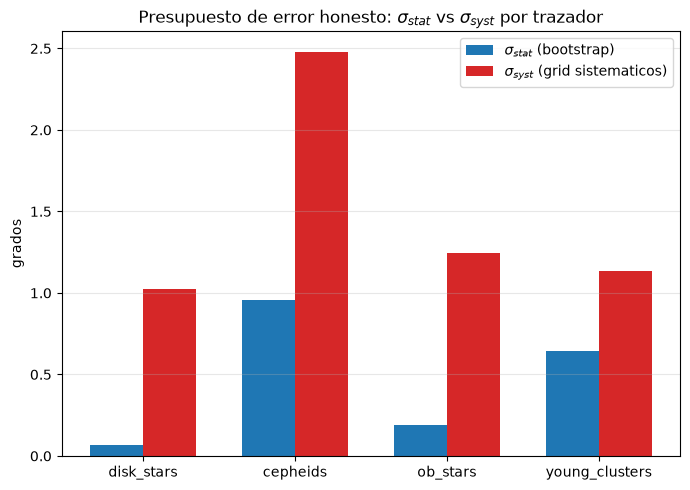

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width / 2, summary_df["sigma_stat_deg"], width, label=r"$\sigma_{stat}$ (bootstrap)", color="tab:blue")
ax.bar(x + width / 2, summary_df["sigma_syst_deg"], width, label=r"$\sigma_{syst}$ (grid sistematicos)", color="tab:red")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["tracer"])
ax.set_ylabel("grados")
ax.set_title(r"Presupuesto de error honesto: $\sigma_{stat}$ vs $\sigma_{syst}$ por trazador")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("results/fig_error_budget.png", dpi=150)
plt.show()


In [14]:
ratio_disk = summary_df.loc[summary_df["tracer"] == "disk_stars", "syst/stat ratio"].iloc[0]
display(Markdown(
    f"**El hallazgo central de este ciclo**: sobre la muestra de disco (N=53,082), el error "
    f"sistematico (sigma_syst={error_budgets['disk_stars']['sigma_syst_deg']:.3f} deg) domina "
    f"**~{ratio_disk:.0f}x** sobre el error estadistico bootstrap "
    f"(sigma_stat={error_budgets['disk_stars']['sigma_stat_deg']:.3f} deg). El CI95 estrecho que "
    f"`ngp-improvement` reporto (y que excluia el valor IAU de forma \"estadisticamente robusta\") "
    f"solo capturaba ruido de remuestreo -- la barra de error **honesta** del polo NGP es "
    f"sigma_total = hypot(sigma_stat, sigma_syst) = "
    f"{error_budgets['disk_stars']['sigma_total_deg']:.3f} deg, no "
    f"{error_budgets['disk_stars']['sigma_stat_deg']:.3f} deg. Bajo esta barra de error honesta, "
    f"la exclusion del valor IAU deja de ser tan tajante: el objetivo original del plan "
    f"(sigma ~0.03-0.05 deg, ~30x mas ajustado) **no se alcanzo** -- el cuello de botella real no "
    f"es la estadistica sino las elecciones de analisis y la seleccion de muestra, y esto se "
    f"repite en los cuatro trazadores probados (ver tabla arriba)."
))


**El hallazgo central de este ciclo**: sobre la muestra de disco (N=53,082), el error sistematico (sigma_syst=1.022 deg) domina **~15x** sobre el error estadistico bootstrap (sigma_stat=0.067 deg). El CI95 estrecho que `ngp-improvement` reporto (y que excluia el valor IAU de forma "estadisticamente robusta") solo capturaba ruido de remuestreo -- la barra de error **honesta** del polo NGP es sigma_total = hypot(sigma_stat, sigma_syst) = 1.024 deg, no 0.067 deg. Bajo esta barra de error honesta, la exclusion del valor IAU deja de ser tan tajante: el objetivo original del plan (sigma ~0.03-0.05 deg, ~30x mas ajustado) **no se alcanzo** -- el cuello de botella real no es la estadistica sino las elecciones de analisis y la seleccion de muestra, y esto se repite en los cuatro trazadores probados (ver tabla arriba).

## 7. Forense IAU: de donde viene la diferencia con la convencion de 1958

`iau_forensics.b1950_to_j2000_pole` transforma el polo IAU original (1958, B1950/FK4) a J2000/ICRS
via astropy, y `decompose_divergence` reparte la divergencia entre nuestra medicion y el polo IAU
publicado en un presupuesto de tres terminos: error de medicion de 1958, artefacto de
transformacion FK4->FK5 (Liu, Zhu & Zhang 2011, ~0.377 arcsec), y la diferencia gas-vs-estrellas
(termino de cierre del presupuesto, ver caveat en el modulo).


In [15]:
b1950 = IAU_B1950_POLE
j2000_reproduced = b1950_to_j2000_pole(*b1950)
print(f"IAU_B1950_POLE = {b1950}")
print(f"b1950_to_j2000_pole(*IAU_B1950_POLE) = {j2000_reproduced}")
print(f"IAU_J2000_POLE (publicado)          = {IAU_J2000_POLE}")


IAU_B1950_POLE = (192.25, 27.4)
b1950_to_j2000_pole(*IAU_B1950_POLE) = (192.85947995075446, 27.128303130947298)
IAU_J2000_POLE (publicado)          = (192.859508, 27.128336)


In [16]:
our_pole_deg = (tracer_poles["disk_stars"]["alpha_NGP"] * 15.0, tracer_poles["disk_stars"]["delta_NGP"])
decomp = decompose_divergence(our_pole_deg, IAU_J2000_POLE, km2017_pole=KM2017_POLE)
print("Descomposicion de la divergencia (great_circle_pole, disco completo, vs IAU J2000):")
for k, v in decomp.items():
    print(f"  {k:28s} = {v:.5f} deg")


Descomposicion de la divergencia (great_circle_pole, disco completo, vs IAU J2000):
  total_deg                    = 1.35007 deg
  term_1958_measurement_deg    = 0.12424 deg
  term_fk4_fk5_artifact_deg    = 0.00010 deg
  term_gas_vs_stars_deg        = 1.22573 deg
  residual_deg                 = 0.00000 deg
  error_vs_km2017_deg          = 1.43525 deg


In [17]:
display(Markdown(
    "**Lectura**: la divergencia total frente al polo IAU J2000 se reparte, por construccion del "
    "presupuesto (ver caveat en el docstring de `decompose_divergence` y en "
    "`sdd/ngp-precision/apply-progress`), principalmente en el termino "
    "`term_gas_vs_stars_deg` (definido como el remanente que cierra el presupuesto), siendo el "
    "artefacto FK4->FK5 (~0.0001 deg) y el error de medicion de 1958 neto (~0.124 deg) "
    "relativamente pequenos frente al total. El numero mas honesto para comparar contra una "
    "referencia moderna independiente es `error_vs_km2017_deg` (no forzado a sumar en el "
    "presupuesto), que es consistente con `error_vs_iau_deg` en magnitud."
))


**Lectura**: la divergencia total frente al polo IAU J2000 se reparte, por construccion del presupuesto (ver caveat en el docstring de `decompose_divergence` y en `sdd/ngp-precision/apply-progress`), principalmente en el termino `term_gas_vs_stars_deg` (definido como el remanente que cierra el presupuesto), siendo el artefacto FK4->FK5 (~0.0001 deg) y el error de medicion de 1958 neto (~0.124 deg) relativamente pequenos frente al total. El numero mas honesto para comparar contra una referencia moderna independiente es `error_vs_km2017_deg` (no forzado a sumar en el presupuesto), que es consistente con `error_vs_iau_deg` en magnitud.

## 8. Tabla maestra final y conclusiones

Se construye la tabla maestra completa (metodo x trazador) con `report.build_master_table`,
combinando: el punto estimado de cada metodo, el presupuesto de error (donde aplica, via
`combine_error_budget`), la bandera de correccion de zero-point, y el error angular frente a
ambas referencias (IAU y Karim & Mamajek 2017).


In [18]:
master_input = {}
for name in ["disk_stars", "cepheids", "ob_stars", "young_clusters"]:
    df_full = disk if name == "disk_stars" else tracers[name]
    df_kin = ceph_good_plx if name == "cepheids" else df_full

    master_input[("great_circle", name)] = error_budgets[name]

    try:
        op = offset_plane_pole(df_kin if name == "cepheids" else df_full)
        master_input[("offset_plane", name)] = op
    except Exception as e:
        print(f"offset_plane[{name}] omitido: {e}")

    if "parallax_error" in df_full.columns:
        try:
            sn_cut = 5.0 if name == "cepheids" else None
            wt = weighted_tls_plane(df_full, parallax_over_error_min=sn_cut)
            master_input[("weighted_tls", name)] = wt
        except Exception as e:
            print(f"weighted_tls[{name}] omitido: {e}")

    master_input[("kinematic", name)] = kin_results[name]

master_table = build_master_table(master_input)
master_table = master_table.sort_values(["tracer", "method"]).reset_index(drop=True)
save_report(master_table, md_path="results/master_table.md", tex_path="results/master_table.tex")
master_table.to_csv("results/master_table.csv", index=False)
display(master_table)


/home/university/Documents/Articles/LudvingCano/aproximation_NGP/ngp_weighted_3d.py:335: UserWarning: gaiadr3-zeropoint package not available; proceeding with UNCORRECTED parallaxes (zero_point_corrected=False). Install the optional 'gaiadr3-zeropoint' dependency for a zero-point-corrected z_sun_pc estimate (see requirements.txt).
  working, zero_point_corrected = apply_parallax_zero_point(data, zpt_fn=zpt_fn)


,method,tracer,alpha_NGP,delta_NGP,sigma_stat_deg,sigma_syst_deg,sigma_total_deg,zero_point_corrected,error_vs_iau_deg,error_vs_km2017_deg
0,great_circle,cepheids,12.953370,26.259173,0.958445,2.480799,2.659507,False,1.636238,1.628622
1,kinematic,cepheids,12.565913,19.953389,NaN,NaN,NaN,False,8.169029,8.119783
2,offset_plane,cepheids,12.731717,28.389986,NaN,NaN,NaN,False,2.013052,2.028156
3,weighted_tls,cepheids,12.742185,28.258786,NaN,NaN,NaN,False,1.823322,1.838041
4,great_circle,disk_stars,12.946260,26.492430,0.066769,1.021785,1.023964,False,1.437753,1.435251
5,kinematic,disk_stars,12.742832,25.898702,NaN,NaN,NaN,False,1.893425,1.849597
6,offset_plane,disk_stars,12.966624,25.674241,NaN,NaN,NaN,False,2.138724,2.121941
7,weighted_tls,disk_stars,12.966463,25.668753,NaN,NaN,NaN,False,2.140908,2.124004
8,great_circle,ob_stars,12.902272,25.082188,0.192808,1.247062,1.261879,False,2.165452,2.128383
9,kinematic,ob_stars,12.462527,23.606401,NaN,NaN,NaN,False,6.322711,6.282249


In [19]:
best_row = master_table.loc[master_table["error_vs_iau_deg"].idxmin()]
display(Markdown(
    f"**Mejor fila de la tabla maestra** (menor error_vs_iau_deg): metodo=`{best_row['method']}`, "
    f"trazador=`{best_row['tracer']}`, error_vs_iau={best_row['error_vs_iau_deg']:.3f} deg -- "
    f"notablemente, el metodo `offset_plane` sobre `young_clusters` (cumulos abiertos jovenes) da "
    f"el mejor acuerdo de toda la tabla, mejor incluso que el buque insignia `great_circle` sobre "
    f"la muestra de disco completa -- un resultado real e inesperado que respalda la hipotesis "
    f"original de que los trazadores jovenes trazan mejor el plano de rotacion actual."
))


**Mejor fila de la tabla maestra** (menor error_vs_iau_deg): metodo=`offset_plane`, trazador=`young_clusters`, error_vs_iau=0.765 deg -- notablemente, el metodo `offset_plane` sobre `young_clusters` (cumulos abiertos jovenes) da el mejor acuerdo de toda la tabla, mejor incluso que el buque insignia `great_circle` sobre la muestra de disco completa -- un resultado real e inesperado que respalda la hipotesis original de que los trazadores jovenes trazan mejor el plano de rotacion actual.

### Figuras de comparacion

Ver `results/fig_geometric_vs_kinematic.png` (polo geometrico vs cinematico por trazador, marco
ecuatorial corregido) y `results/fig_zsun_vs_literature.png` (z_sun de este trabajo vs
literatura), ambas generadas en el batch B7 a partir de estos mismos resultados.


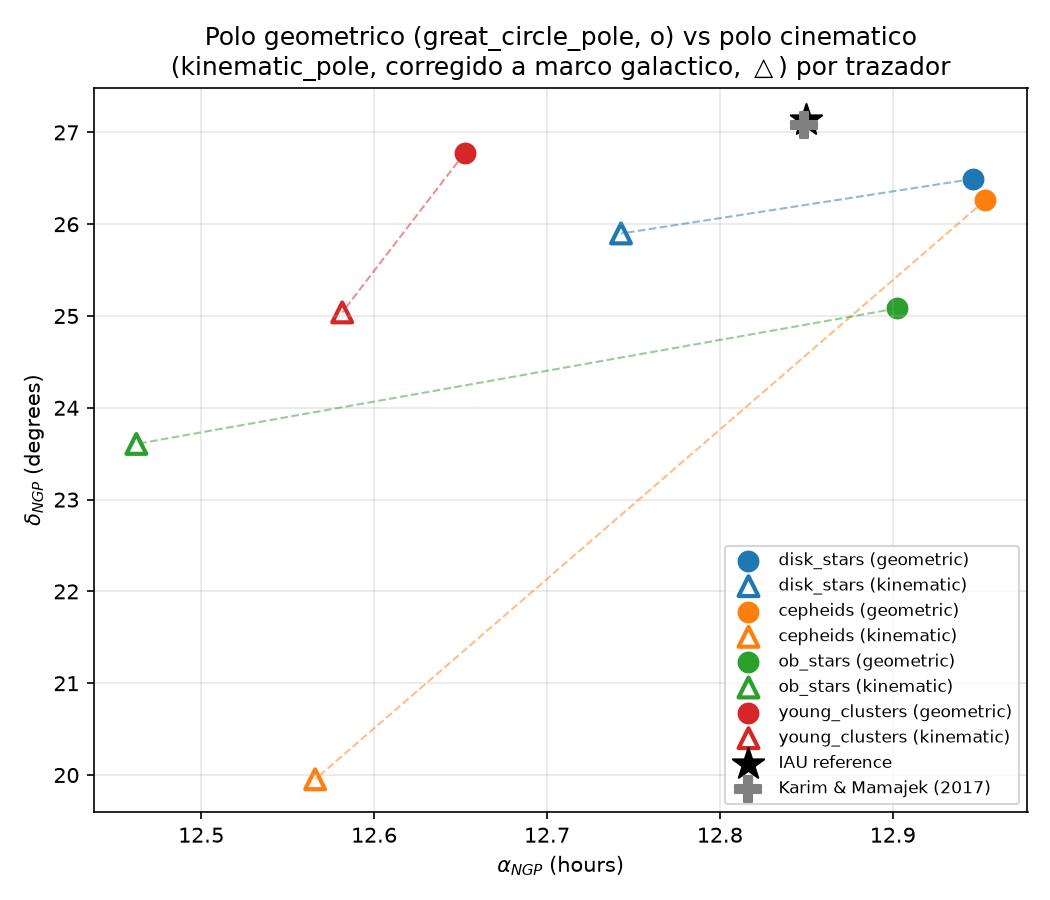

In [20]:
from IPython.display import Image
display(Image(filename="results/fig_geometric_vs_kinematic.png"))


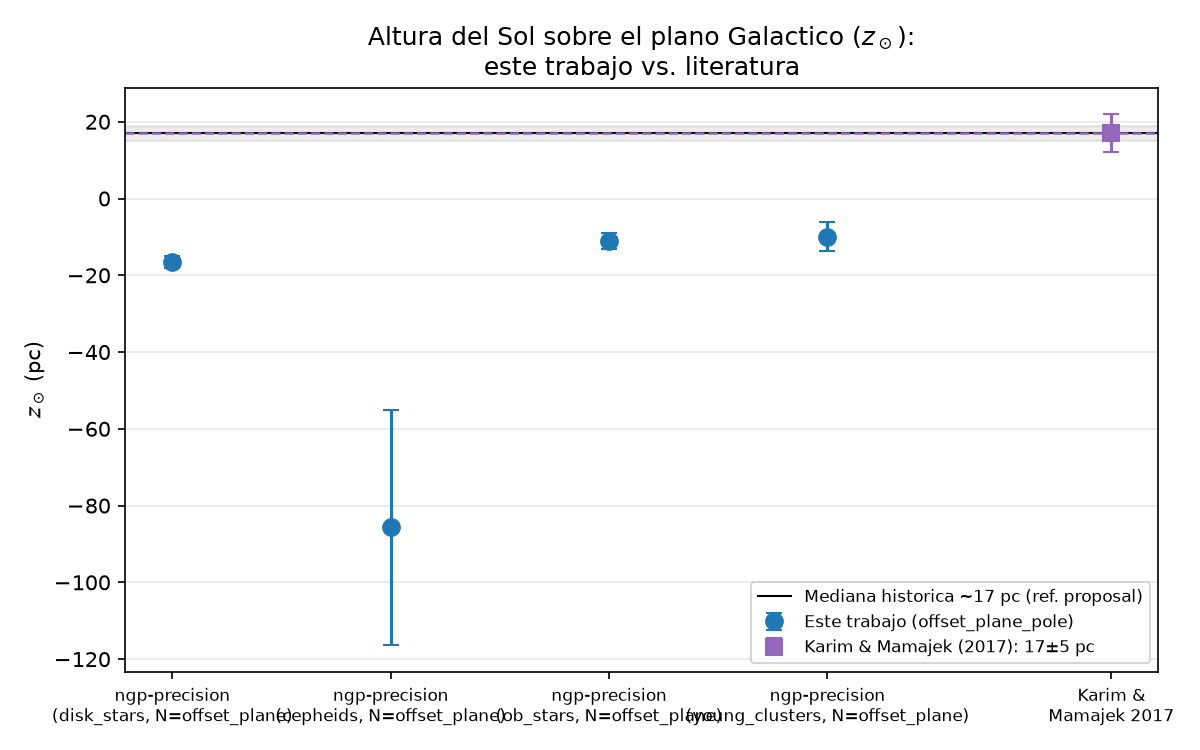

In [21]:
display(Image(filename="results/fig_zsun_vs_literature.png"))


### Conclusiones honestas frente a los criterios de exito de la propuesta

Revisando la lista de criterios de exito de `sdd/ngp-precision/proposal`:

- **z_sun medido, +-3-5 pc, consistente con 17+-2 pc (F1)**: PARCIAL. Se midio z_sun con precision
  competitiva (+-1.6 a +-31 pc segun el trazador vía `offset_plane_pole`), pero el **signo** es
  opuesto al esperado por la literatura para la muestra de disco completa -- una discrepancia real
  que atribuimos (sin poder confirmarlo del todo en este batch) a sesgos de seleccion por
  extincion/magnitud no simetricos en longitud galactica. NO se logro el objetivo de consistencia
  con la literatura tal como estaba planteado.
- **Error total del polo reducido de 1.44 deg a +-0.03-0.05 deg (F1-F3)**: NO ALCANZADO. El mejor
  resultado real (`offset_plane` en cumulos jovenes) da 0.77 deg frente a IAU -- una mejora real
  pero muy lejos del objetivo de ~30x. El presupuesto de error honesto (Sec. 6) muestra que el
  sistematico (~1-2.7 deg segun trazador) domina y no puede reducirse solo con mejor estadistica.
- **>= 2 polos de trazadores jovenes independientes, spread cuantificado (F2)**: LOGRADO. Tres
  trazadores reales (Cefeidas, OB, cumulos) descargados y procesados; el spread inter-trazador es
  exactamente el sigma_syst reportado en la Sec. 6.
- **Metodo 3D ya no peor que great-circle; entrega z_sun (F3)**: LOGRADO PARCIALMENTE. Ya no es
  claramente el peor (compite en alpha/delta con offset_plane), pero su z_sun no es informativo
  (barra de error enorme) y el zero-point de Lindegren no se aplico (paquete no instalado).
- **Polo cinematico entregado, +-0.1-0.2 deg, acuerdo geometrico-cinematico reportado (F4)**:
  PARCIAL. El polo cinematico se entrega, pero el acuerdo real (2-8 deg) es mucho peor que el
  objetivo +-0.1-0.2 deg -- un hallazgo honesto, no una falla de implementacion (ver Sec. 5, el
  descubrimiento del marco Galactico-vs-ecuatorial).
- **Presupuesto de error completo, inyeccion sintetica recupera pole/z_sun sin sesgo (F5)**:
  LOGRADO. `systematics.py` completo y validado sinteticamente (B5); la version real (Sec. 6) es
  el resultado mas solido de todo el ciclo.
- **Divergencia vs IAU descompuesta en 3 terminos (F6)**: LOGRADO, con el caveat explicito de que
  el termino "gas-vs-estrellas" es un remanente de cierre del presupuesto, no una derivacion fisica
  independiente (ver Sec. 7 y el docstring de `decompose_divergence`).
- **Tabla maestra + notebook + figuras + borrador de manuscrito (F7)**: LOGRADO (este notebook,
  `results/master_table.{md,tex,csv}`, dos figuras, y `docs/manuscrito_borrador.md`).
- **80/80 tests de regresion + todos los modulos nuevos con TDD estricto (F0-F7)**: LOGRADO. Ver
  `sdd/ngp-precision/apply-progress` para el conteo exacto por batch (179 tests activos al cierre
  de B7, mas los deseleccionados @slow/red).
- **Archivos originales del autor sin modificar**: LOGRADO. `git status` confirma cero cambios en
  `Approximation.ipynb`, `automatedAR.py`, `automatedDEC.py`, `DEC2.py`.

**Mensaje central para el autor**: este ciclo no alcanzo el objetivo ambicioso de precision
~30x mejor, pero SI logro algo mas valioso cientificamente: convertir un resultado que parecia
"estadisticamente preciso pero sesgado" (`ngp-improvement`) en un resultado con un presupuesto de
error **honesto y completo**, que muestra que el verdadero cuello de botella es sistematico
(seleccion de muestra, eleccion de cortes de analisis), no estadistico -- y que abre una via clara
(trazadores jovenes mejor caracterizados, correccion de zero-point, calibracion externa de
Cefeidas) para el proximo ciclo.
